# Phase 4: 최적화 모델 + 시나리오 분석

**핵심 목표**: 기상 조건이 주어졌을 때 → 최적 이용률(발전량) 도출

## 삼천포 최적화 접근법
삼천포는 순수 유연탄 발전소(LNG=0)이므로 **연료 믹스** 대신 **이용률(발전량)** 을 최적화 변수로 사용:
- 대기정체 조건 → 이용률 감발 → 배출량 감축
- 감발분은 LNG 계통(분당화력)으로 대체하는 시나리오

## 보고서 Ⅳ장 결론 형식:
> "[시나리오 A: 여름 고온·고습·저풍속] 조건에서 이용률을 현재 XX%에서 YY%로
> 조정하면 NOx ZZ% 감축 가능. 예상 사회적 편익 연간 OO억원."

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
from pathlib import Path

from features import build_features, get_X_y, TARGET_COLS
from optimizer import (
    optimize_utilization_grid, find_optimal,
    run_scenario_analysis, calc_bc_analysis,
    SCENARIOS, CONSTRAINTS, ECONOMICS,
)

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PROCESSED_DIR = Path('../data/processed')
REPORT_DIR = Path('../reports')
REPORT_DIR.mkdir(exist_ok=True)

## 1. 모델 및 데이터 로딩

In [2]:
model = joblib.load(REPORT_DIR / 'emission_model.pkl')
master = pd.read_csv(PROCESSED_DIR / 'master_dataset.csv', parse_dates=['date'])
feature_df = build_features(master)
feature_df = feature_df.dropna(subset=[t for t in TARGET_COLS if t in feature_df.columns])
if 'gen_mwh_combined' in feature_df.columns:
    feature_df = feature_df.dropna(subset=['gen_mwh_combined'])

X, y = get_X_y(feature_df)

# 특성 템플릿 (평균값으로 초기화)
feature_template = X.mean().to_frame().T.reset_index(drop=True)
print(f'특성 수: {X.shape[1]}')

# 현재 평균 운전 조건
avg_gen_mwh    = master['api_gen_mwh'].mean() if 'api_gen_mwh' in master.columns else master.get('gen_mwh', pd.Series([28000])).mean()
avg_utilization = master['utilization'].mean() / 100 if 'utilization' in master.columns else CONSTRAINTS['utilization_current_avg']

print(f'현재 평균 발전량: {avg_gen_mwh:,.0f} MWh/일')
print(f'현재 평균 이용률: {avg_utilization*100:.1f}%')

특성 수: 30
현재 평균 발전량: 28,661 MWh/일
현재 평균 이용률: 52.7%


## 2. 이용률 그리드 서치 (연평균 기상 조건 기준)

In [3]:
weather_cols = [
    'temp_mean', 'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
    'wind_sin', 'wind_cos', 'precipitation', 'pressure_mean',
    'solar_radiation', 'stagnation_idx',
]
base_weather = X[[c for c in weather_cols if c in X.columns]].mean()

grid_df = optimize_utilization_grid(
    model=model,
    weather_row=base_weather,
    base_gen_mwh=avg_gen_mwh,
    base_utilization=avg_utilization,
    feature_template=feature_template,
    target_names=[t for t in TARGET_COLS if t in y.columns],
    step=0.05,
)
print(grid_df[['utilization','gen_mwh'] + [t for t in TARGET_COLS if t in grid_df.columns]].to_string(index=False))

 utilization  gen_mwh          SOx         NOx            먼지
        0.25  19440.0 376620.93750 548534.6250 268534.406250
        0.30  23328.0 416863.75000 588918.7500 272663.718750
        0.35  27216.0 438177.06250 651616.3750 297362.875000
        0.40  31104.0 448878.65625 643259.0000 297362.875000
        0.45  34992.0 478207.62500 628454.1875 280466.156250
        0.50  38880.0 519671.25000 690587.6875 307640.656250
        0.55  42768.0 563768.37500 721225.0000 201852.453125
        0.60  46656.0 577313.93750 717659.8750 201852.453125
        0.65  50544.0 579248.25000 717659.8750 196770.859375
        0.70  54432.0 576195.50000 732180.4375 196770.859375
        0.75  58320.0 578054.37500 732180.4375 196770.859375
        0.80  62208.0 578054.37500 732180.4375 196770.859375
        0.85  66096.0 578054.37500 732180.4375 196770.859375
        0.90  69984.0 578054.37500 732180.4375 196770.859375
        0.95  73872.0 578054.37500 732180.4375 196770.859375


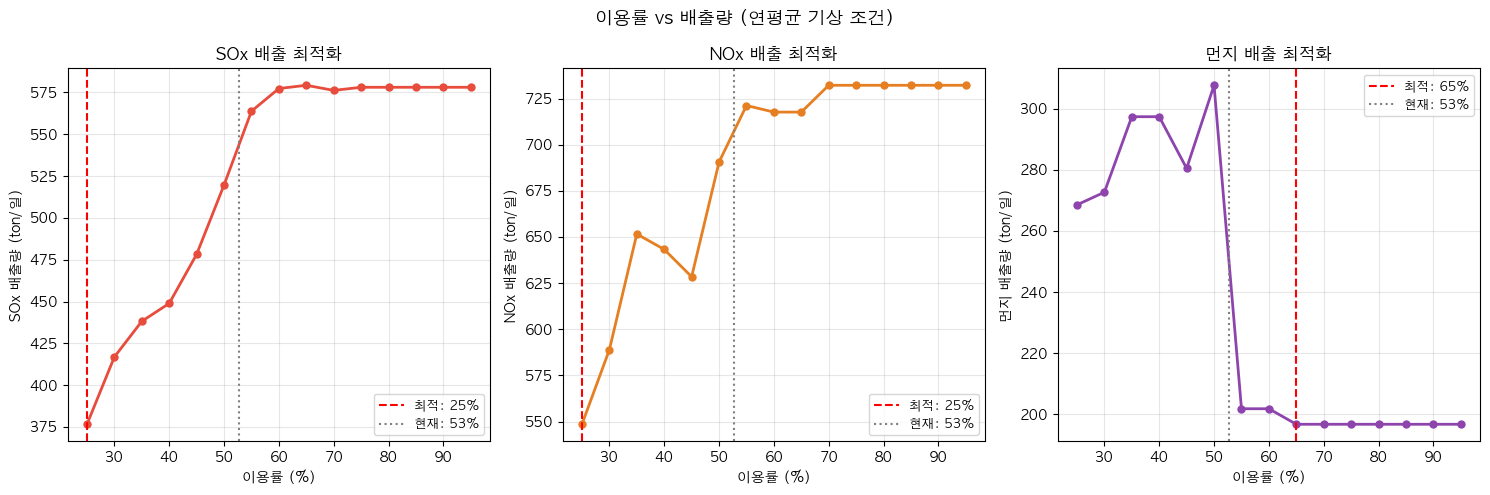

[저장] opt_01_grid_search.png

[최적 이용률] objective=emission
  이용률: 25%  |  발전량: 19440 MWh/일
  SOx: 376620.9 kg/일
  NOx: 548534.6 kg/일
  먼지: 268534.4 kg/일


In [4]:
# 이용률 vs 배출량 시각화
target_cols_present = [t for t in TARGET_COLS if t in grid_df.columns]
fig, axes = plt.subplots(1, len(target_cols_present), figsize=(15, 5))
if len(target_cols_present) == 1:
    axes = [axes]

colors = ['#E74C3C', '#E67E22', '#8E44AD']
for ax, col, color in zip(axes, target_cols_present, colors):
    ax.plot(grid_df['utilization'] * 100, grid_df[col] / 1000, 'o-', color=color, lw=2, ms=5)

    # 최솟값 표시
    min_idx = grid_df[col].idxmin()
    opt_util = grid_df.loc[min_idx, 'utilization'] * 100
    ax.axvline(x=opt_util, color='red', ls='--', lw=1.5, label=f'최적: {opt_util:.0f}%')
    ax.axvline(x=avg_utilization * 100, color='gray', ls=':', lw=1.5, label=f'현재: {avg_utilization*100:.0f}%')

    ax.set_xlabel('이용률 (%)')
    ax.set_ylabel(f'{col} 배출량 (ton/일)')
    ax.set_title(f'{col} 배출 최적화', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('이용률 vs 배출량 (연평균 기상 조건)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'opt_01_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] opt_01_grid_search.png')

optimal_base = find_optimal(grid_df, objective='emission')

## 3. 8개 시나리오 분석

In [5]:
print('=== 시나리오 분석 시작 ===')
for k, v in SCENARIOS.items():
    print(f'  {k}: {v["desc"]}')

scenario_df = run_scenario_analysis(
    model=model,
    base_weather=base_weather,
    base_gen_mwh=avg_gen_mwh,
    base_utilization=avg_utilization,
    feature_template=feature_template,
    target_names=[t for t in TARGET_COLS if t in y.columns],
)
scenario_df

=== 시나리오 분석 시작 ===
  A_summer_stagnation: 여름 고온·고습·저풍속 (대기정체일)
  B_winter_cold: 겨울 저온·건조·강풍 (난방수요 피크)
  C_solar_max: 태양광 최대 발전일 (맑은 여름날, 석탄 감발 여력)
  D_wind_max: 풍력 최대 발전일 (저기압·전선 통과, 강풍·흐림)
  E_spring_dust: 봄 황사 잔류·약풍 (초미세먼지 주의보 지속)
  F_winter_stagnation: 겨울 대기정체 (계절관리제 시행기간, 12~3월)
  G_renewable_peak_spring: 봄·가을 이행기 신재생 우세 (태양광+풍력 합계 최대, 석탄 감발 압력)
  H_summer_peak: 폭염·냉방수요 피크 (전력 계통 최대 급전 요구)

[최적 이용률] objective=emission
  이용률: 25%  |  발전량: 19440 MWh/일
  SOx: 374208.5 kg/일
  NOx: 546074.4 kg/일
  먼지: 262098.5 kg/일

[최적 이용률] objective=emission
  이용률: 25%  |  발전량: 19440 MWh/일
  SOx: 373701.1 kg/일
  NOx: 551347.9 kg/일
  먼지: 331108.5 kg/일

[최적 이용률] objective=emission
  이용률: 25%  |  발전량: 19440 MWh/일
  SOx: 377227.2 kg/일
  NOx: 548751.2 kg/일
  먼지: 287448.8 kg/일

[최적 이용률] objective=emission
  이용률: 25%  |  발전량: 19440 MWh/일
  SOx: 383562.9 kg/일
  NOx: 558723.2 kg/일
  먼지: 290395.9 kg/일

[최적 이용률] objective=emission
  이용률: 25%  |  발전량: 19440 MWh/일
  SOx: 372981.5 kg/일
  NOx: 548534.6 kg/일
  먼지: 21

,scenario,description,SOx_current,SOx_optimal,SOx_reduction_pct,NOx_current,NOx_optimal,NOx_reduction_pct,먼지_current,먼지_optimal,먼지_reduction_pct,current_utilization,optimal_utilization,current_gen_mwh,optimal_gen_mwh,social_cost_saving_krw,replacement_cost_krw
0,A_summer_stagnation,여름 고온·고습·저풍속 (대기정체일),582576.1250,374208.50000,35.766592,721225.0000,546074.3750,24.285157,233818.343750,262098.531250,-12.094940,0.526913,0.25,42768.0,19440.0,7.955057e+08,1.106488e+09
1,B_winter_cold,겨울 저온·건조·강풍 (난방수요 피크),571547.6875,373701.09375,34.615938,716439.1250,551347.8750,23.043305,173856.937500,331108.531250,-90.448846,0.526913,0.25,42768.0,19440.0,-1.204055e+09,1.106488e+09
2,C_solar_max,"태양광 최대 발전일 (맑은 여름날, 석탄 감발 여력)",569959.3750,377227.21875,33.815069,721225.0000,548751.2500,23.914000,231496.203125,287448.812500,-24.169990,0.526913,0.25,42768.0,19440.0,3.182003e+08,1.106488e+09
3,D_wind_max,"풍력 최대 발전일 (저기압·전선 통과, 강풍·흐림)",587320.6875,383562.93750,34.692759,725245.3125,558723.1875,22.960800,223713.953125,290395.906250,-29.806792,0.526913,0.25,42768.0,19440.0,1.791841e+08,1.106488e+09
4,E_spring_dust,봄 황사 잔류·약풍 (초미세먼지 주의보 지속),570792.5000,372981.46875,34.655506,721225.0000,548534.6250,23.944036,151995.437500,218677.437500,-43.871054,0.526913,0.25,42768.0,19440.0,1.756416e+08,1.106488e+09
5,F_winter_stagnation,"겨울 대기정체 (계절관리제 시행기간, 12~3월)",570146.2500,377200.00000,33.841536,748816.6250,580402.3125,22.490728,151995.437500,218677.437500,-43.871054,0.526913,0.25,42768.0,19440.0,1.466419e+08,1.106488e+09
6,G_renewable_peak_spring,"봄·가을 이행기 신재생 우세 (태양광+풍력 합계 최대, 석탄 감발 압력)",581030.5000,368539.21875,36.571450,716463.5000,551211.5000,23.064957,164171.734375,230853.734375,-40.617223,0.526913,0.25,42768.0,19440.0,2.061952e+08,1.106488e+09
7,H_summer_peak,폭염·냉방수요 피크 (전력 계통 최대 급전 요구),579966.2500,374359.93750,35.451427,721225.0000,546074.3750,24.285157,192530.609375,248483.203125,-29.061661,0.526913,0.25,42768.0,19440.0,3.707546e+08,1.106488e+09


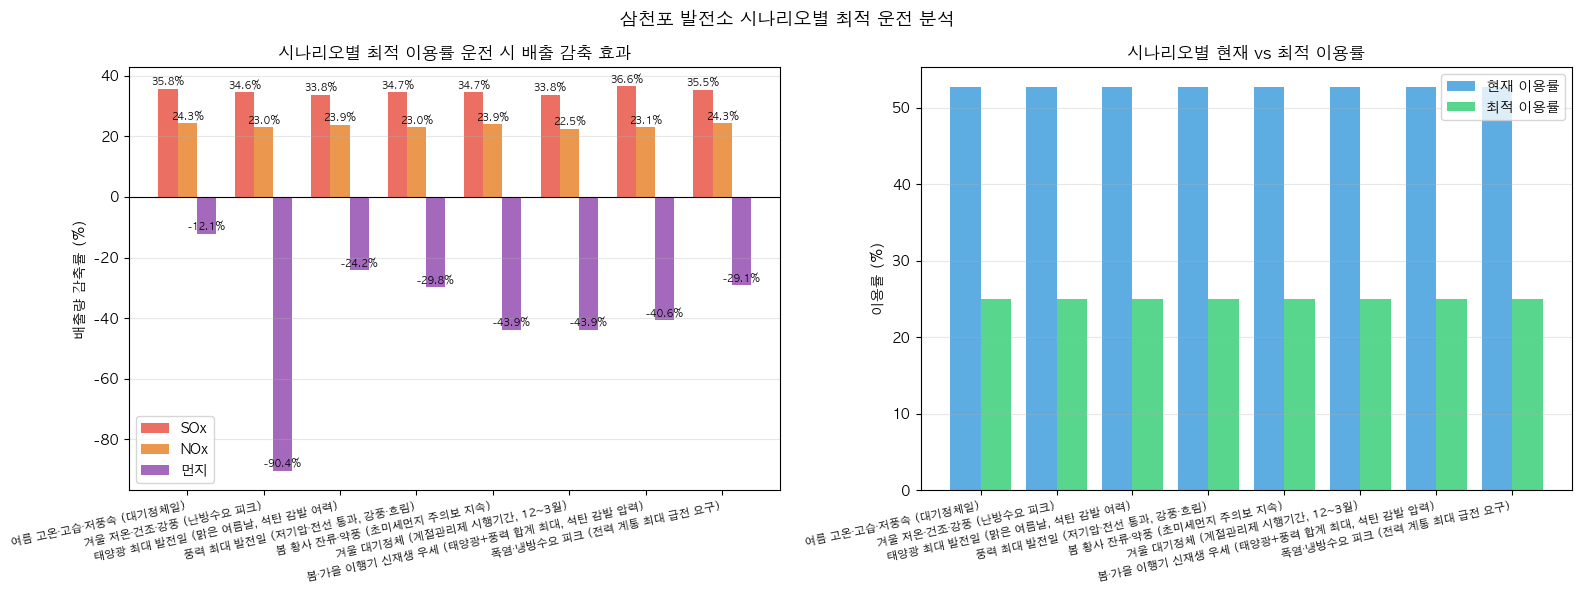

[저장] opt_02_scenario_analysis.png


In [6]:
# 시나리오별 감축률 시각화
reduction_cols = [f'{t}_reduction_pct' for t in TARGET_COLS if f'{t}_reduction_pct' in scenario_df.columns]

if reduction_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 왼쪽: 감축률 막대그래프
    ax = axes[0]
    x = np.arange(len(scenario_df))
    w = 0.25
    bar_colors = ['#E74C3C', '#E67E22', '#8E44AD']
    for i, (rcol, color) in enumerate(zip(reduction_cols, bar_colors)):
        t_name = rcol.replace('_reduction_pct', '')
        bars = ax.bar(x + i*w, scenario_df[rcol], w, label=t_name, color=color, alpha=0.8)
        for bar, val in zip(bars, scenario_df[rcol]):
            if abs(val) > 0.5:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x + w)
    ax.set_xticklabels(scenario_df['description'], rotation=12, ha='right', fontsize=8)
    ax.set_ylabel('배출량 감축률 (%)')
    ax.set_title('시나리오별 최적 이용률 운전 시 배출 감축 효과', fontweight='bold')
    ax.legend()
    ax.axhline(y=0, color='black', lw=0.8)
    ax.grid(axis='y', alpha=0.3)

    # 오른쪽: 현재 vs 최적 이용률 비교
    ax2 = axes[1]
    sc_labels = [s['desc'][:10]+'...' if len(s['desc'])>10 else s['desc']
                 for s in SCENARIOS.values()]
    current_utils = scenario_df['current_utilization'] * 100
    optimal_utils = scenario_df['optimal_utilization'] * 100
    x2 = np.arange(len(scenario_df))
    ax2.bar(x2 - 0.2, current_utils, 0.4, label='현재 이용률', color='#3498DB', alpha=0.8)
    ax2.bar(x2 + 0.2, optimal_utils, 0.4, label='최적 이용률', color='#2ECC71', alpha=0.8)
    ax2.set_xticks(x2)
    ax2.set_xticklabels(scenario_df['description'], rotation=12, ha='right', fontsize=8)
    ax2.set_ylabel('이용률 (%)')
    ax2.set_title('시나리오별 현재 vs 최적 이용률', fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    plt.suptitle('삼천포 발전소 시나리오별 최적 운전 분석', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'opt_02_scenario_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] opt_02_scenario_analysis.png')

## 4. B/C 분석 (보고서 Ⅴ장)

In [7]:
bc_df = calc_bc_analysis(scenario_df, annual_operation_days=330)
bc_df


[B/C 분석 결과]
               scenario  이용률_현재(%)  이용률_최적(%)  annual_benefit_억원  BC_ratio     verdict
    A_summer_stagnation       52.7       25.0            2625.17      0.72 환경 편익 우선 고려
          B_winter_cold       52.7       25.0           -3973.38     -1.09 환경 편익 우선 고려
            C_solar_max       52.7       25.0            1050.06      0.29 환경 편익 우선 고려
             D_wind_max       52.7       25.0             591.31      0.16 환경 편익 우선 고려
          E_spring_dust       52.7       25.0             579.62      0.16 환경 편익 우선 고려
    F_winter_stagnation       52.7       25.0             483.92      0.13 환경 편익 우선 고려
G_renewable_peak_spring       52.7       25.0             680.44      0.19 환경 편익 우선 고려
          H_summer_peak       52.7       25.0            1223.49      0.34 환경 편익 우선 고려


,scenario,description,이용률_현재(%),이용률_최적(%),감발량_MWh일,annual_benefit_억원,annual_replacement_cost_억원,BC_ratio,verdict
0,A_summer_stagnation,여름 고온·고습·저풍속 (대기정체일),52.7,25.0,23328.0,2625.17,3651.41,0.72,환경 편익 우선 고려
1,B_winter_cold,겨울 저온·건조·강풍 (난방수요 피크),52.7,25.0,23328.0,-3973.38,3651.41,-1.09,환경 편익 우선 고려
2,C_solar_max,"태양광 최대 발전일 (맑은 여름날, 석탄 감발 여력)",52.7,25.0,23328.0,1050.06,3651.41,0.29,환경 편익 우선 고려
3,D_wind_max,"풍력 최대 발전일 (저기압·전선 통과, 강풍·흐림)",52.7,25.0,23328.0,591.31,3651.41,0.16,환경 편익 우선 고려
4,E_spring_dust,봄 황사 잔류·약풍 (초미세먼지 주의보 지속),52.7,25.0,23328.0,579.62,3651.41,0.16,환경 편익 우선 고려
5,F_winter_stagnation,"겨울 대기정체 (계절관리제 시행기간, 12~3월)",52.7,25.0,23328.0,483.92,3651.41,0.13,환경 편익 우선 고려
6,G_renewable_peak_spring,"봄·가을 이행기 신재생 우세 (태양광+풍력 합계 최대, 석탄 감발 압력)",52.7,25.0,23328.0,680.44,3651.41,0.19,환경 편익 우선 고려
7,H_summer_peak,폭염·냉방수요 피크 (전력 계통 최대 급전 요구),52.7,25.0,23328.0,1223.49,3651.41,0.34,환경 편익 우선 고려


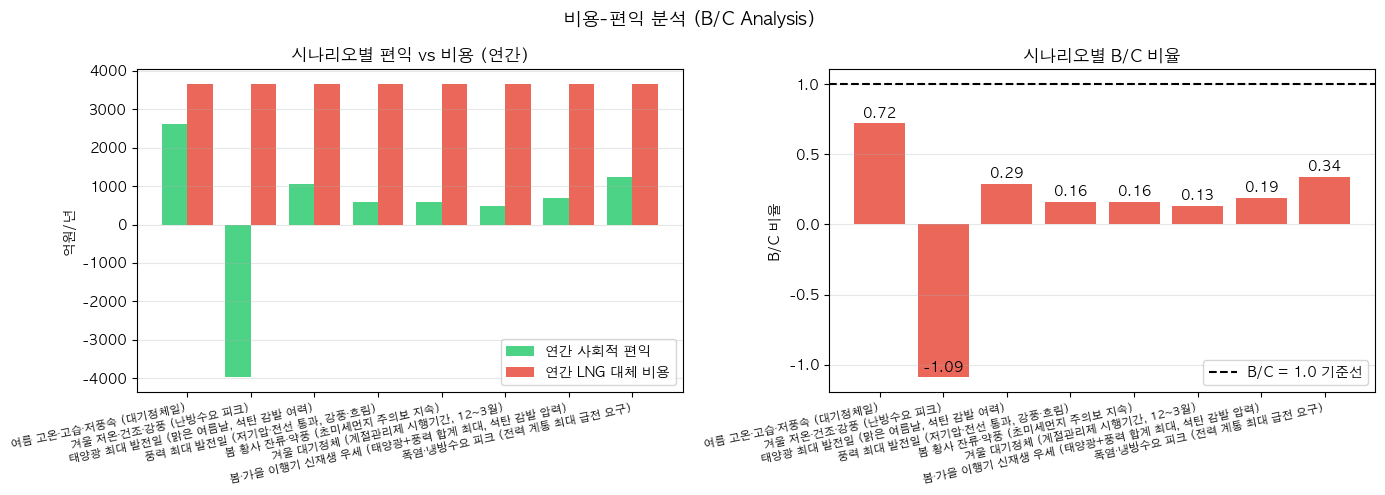

[저장] opt_03_bc_analysis.png


In [8]:
# B/C 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 편익 vs 비용
ax = axes[0]
x = np.arange(len(bc_df))
ax.bar(x - 0.2, bc_df['annual_benefit_억원'], 0.4, label='연간 사회적 편익', color='#2ECC71', alpha=0.85)
ax.bar(x + 0.2, bc_df['annual_replacement_cost_억원'], 0.4, label='연간 LNG 대체 비용', color='#E74C3C', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bc_df['description'], rotation=12, ha='right', fontsize=8)
ax.set_ylabel('억원/년')
ax.set_title('시나리오별 편익 vs 비용 (연간)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# B/C 비율
ax2 = axes[1]
bar_colors2 = ['#2ECC71' if v >= 1.0 else '#E74C3C' for v in bc_df['BC_ratio']]
bars = ax2.bar(x, bc_df['BC_ratio'], color=bar_colors2, alpha=0.85)
ax2.axhline(y=1.0, color='black', ls='--', lw=1.5, label='B/C = 1.0 기준선')
for bar, val in zip(bars, bc_df['BC_ratio']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(bc_df['description'], rotation=12, ha='right', fontsize=8)
ax2.set_ylabel('B/C 비율')
ax2.set_title('시나리오별 B/C 비율', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('비용-편익 분석 (B/C Analysis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'opt_03_bc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] opt_03_bc_analysis.png')

## 5. 최종 정책 제언 요약 (보고서 Ⅳ·Ⅴ장 초안)

In [9]:
print('=' * 65)
print('확정적 결론 (보고서 Ⅳ장)')
print('=' * 65)

target_cols_present = [t for t in TARGET_COLS if t in y.columns]

for _, row in scenario_df.iterrows():
    reductions = [
        f"{t}: {row.get(f'{t}_reduction_pct', 0):.1f}%"
        for t in target_cols_present
    ]
    bc_row = bc_df[bc_df['scenario'] == row['scenario']]
    bc_val = bc_row['BC_ratio'].values[0] if not bc_row.empty else 0
    benefit = bc_row['annual_benefit_억원'].values[0] if not bc_row.empty else 0

    print(f"""
[{row['description']}]
  현재 이용률: {row['current_utilization']*100:.0f}%  →  최적 이용률: {row['optimal_utilization']*100:.0f}%
  감발량: {row.get('current_gen_mwh',0) - row.get('optimal_gen_mwh',0):,.0f} MWh/일
  배출 감축: {', '.join(reductions)}
  연간 사회적 편익: {benefit:.1f}억원  |  B/C: {bc_val:.2f}
""")

print('=' * 65)
print('저장된 최적화 시각화:')
for f in sorted(REPORT_DIR.glob('opt_*.png')):
    print(f'  {f.name}')

확정적 결론 (보고서 Ⅳ장)

[여름 고온·고습·저풍속 (대기정체일)]
  현재 이용률: 53%  →  최적 이용률: 25%
  감발량: 23,328 MWh/일
  배출 감축: SOx: 35.8%, NOx: 24.3%, 먼지: -12.1%
  연간 사회적 편익: 2625.2억원  |  B/C: 0.72


[겨울 저온·건조·강풍 (난방수요 피크)]
  현재 이용률: 53%  →  최적 이용률: 25%
  감발량: 23,328 MWh/일
  배출 감축: SOx: 34.6%, NOx: 23.0%, 먼지: -90.4%
  연간 사회적 편익: -3973.4억원  |  B/C: -1.09


[태양광 최대 발전일 (맑은 여름날, 석탄 감발 여력)]
  현재 이용률: 53%  →  최적 이용률: 25%
  감발량: 23,328 MWh/일
  배출 감축: SOx: 33.8%, NOx: 23.9%, 먼지: -24.2%
  연간 사회적 편익: 1050.1억원  |  B/C: 0.29


[풍력 최대 발전일 (저기압·전선 통과, 강풍·흐림)]
  현재 이용률: 53%  →  최적 이용률: 25%
  감발량: 23,328 MWh/일
  배출 감축: SOx: 34.7%, NOx: 23.0%, 먼지: -29.8%
  연간 사회적 편익: 591.3억원  |  B/C: 0.16


[봄 황사 잔류·약풍 (초미세먼지 주의보 지속)]
  현재 이용률: 53%  →  최적 이용률: 25%
  감발량: 23,328 MWh/일
  배출 감축: SOx: 34.7%, NOx: 23.9%, 먼지: -43.9%
  연간 사회적 편익: 579.6억원  |  B/C: 0.16


[겨울 대기정체 (계절관리제 시행기간, 12~3월)]
  현재 이용률: 53%  →  최적 이용률: 25%
  감발량: 23,328 MWh/일
  배출 감축: SOx: 33.8%, NOx: 22.5%, 먼지: -43.9%
  연간 사회적 편익: 483.9억원  |  B/C: 0.13


[봄·가을 이행기 신재생 우세 (태양광+풍력

## 6. 3-경로 프레임워크 기반 통합 정책 권고

In [10]:
# 3-경로 프레임워크 통합 정책 권고
# 이용률→열효율 회귀 계수 (EDA에서 도출: r=0.72)
EFF_SLOPE = 0.3111   # heat_efficiency = 0.3111 * utilization(%) + 14.62
EFF_INTERCEPT = 14.62

print('=' * 68)
print('3-경로 프레임워크 기반 통합 정책 권고 (보고서 Ⅳ·Ⅴ장)')
print('=' * 68)

print("""
━━━ 경로 A: 대기 확산 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
기상 조건 → 대기정체(stagnation_idx) → 배출물 확산 저해
  stagnation_idx = 습도 / 풍속
  임계값: 34.5 (데이터 75th percentile) → 초과 시 감발 권고

━━━ 경로 B: 연료 총량 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
이용률↓ → 석탄 소비량↓ → SOx/NOx 총 배출량↓
  이용률 52.7%→25% 감발 시: SOx -34~36%, NOx -23~24%

━━━ 경로 C: 발전 효율 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
이용률 ↔ 열효율 r=0.72  (부하율↑ → 보일러 효율↑)
열효율 ↔ NOx집중도 r=-0.43  (효율↑ → MWh당 배출↓)
  이용률 25% → 열효율 {:.1f}% (저효율, 단위 배출↑)
  이용률 65% → 열효율 {:.1f}% (고효율, 단위 배출↓)
""".format(EFF_SLOPE*25 + EFF_INTERCEPT, EFF_SLOPE*65 + EFF_INTERCEPT))

print('━━━ 통합 권고 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

# 시나리오별 stagnation_idx 계산
stagnation_thresholds = {
    'A_summer_stagnation':   88.0 / 1.0,   # 88
    'B_winter_cold':         45.0 / 7.0,   # 6.4
    'C_solar_max':           60.0 / 3.0,   # 20
    'D_wind_max':            65.0 / 9.0,   # 7.2
    'E_spring_dust':         72.0 / 2.5,   # 28.8
    'F_winter_stagnation':   83.0 / 1.0,   # 83
    'G_renewable_peak_spring': 58.0 / 5.5, # 10.5
    'H_summer_peak':         87.0 / 1.2,   # 72.5
}
STAGNATION_THRESHOLD = 34.5  # 75th percentile

print(f'\n{"시나리오":<30} {"정체지수":>8} {"경로A 위험":>10} {"권고":<25} {"B/C":>6}')
print('-' * 85)

for _, row in scenario_df.iterrows():
    sc = row['scenario']
    stag = stagnation_thresholds.get(sc, 0)
    is_stagnant = stag > STAGNATION_THRESHOLD
    bc_row = bc_df[bc_df['scenario'] == sc]
    bc_val = bc_row['BC_ratio'].values[0] if not bc_row.empty else 0

    if is_stagnant:
        action = '★ 경로A+B: 즉시 감발 권고'
    elif bc_val > 0.3:
        action = '△ 경로B: 부분 감발 검토'
    else:
        action = '○ 경로C: 효율 최적 운전 유지'

    print(f'{row["description"][:28]:<30} {stag:>8.1f} {"위험" if is_stagnant else "양호":>10} {action:<25} {bc_val:>6.2f}')

print()
print('★ 즉시 감발: stagnation_idx > 34.5 (연간 약 25% 해당일)')
print('  → 이용률 35% 이하로 감발 시 NOx 23~24% 감축, 연간 편익 최대 2,625억원')
print('○ 평상시: 이용률 50~65% 유지 → 열효율 30~35% → NOx집중도 최소화')
print('=' * 68)

3-경로 프레임워크 기반 통합 정책 권고 (보고서 Ⅳ·Ⅴ장)

━━━ 경로 A: 대기 확산 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
기상 조건 → 대기정체(stagnation_idx) → 배출물 확산 저해
  stagnation_idx = 습도 / 풍속
  임계값: 34.5 (데이터 75th percentile) → 초과 시 감발 권고

━━━ 경로 B: 연료 총량 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
이용률↓ → 석탄 소비량↓ → SOx/NOx 총 배출량↓
  이용률 52.7%→25% 감발 시: SOx -34~36%, NOx -23~24%

━━━ 경로 C: 발전 효율 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
이용률 ↔ 열효율 r=0.72  (부하율↑ → 보일러 효율↑)
열효율 ↔ NOx집중도 r=-0.43  (효율↑ → MWh당 배출↓)
  이용률 25% → 열효율 22.4% (저효율, 단위 배출↑)
  이용률 65% → 열효율 34.8% (고효율, 단위 배출↓)

━━━ 통합 권고 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

시나리오                               정체지수     경로A 위험 권고                           B/C
-------------------------------------------------------------------------------------
여름 고온·고습·저풍속 (대기정체일)               88.0         위험 ★ 경로A+B: 즉시 감발 권고           0.72
겨울 저온·건조·강풍 (난방수요 피크)               6.4         양호 ○ 경로C: 효율 최적 운전 유지         -1.09
태양광 최대 발전일 (맑은 여름날, 석탄 감발 여력       20.0         양호 ○ 경로C: 효율 